<a href="https://colab.research.google.com/github/sittidetw/dads5001_midterm_project/blob/main/EDA_HIV_Proactive_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demographic and Spatial Factors to Enhance Proactive HIV Screening Efficiency

In [19]:
!git clone https://github.com/sittidetw/dads5001_midterm_project.git

fatal: destination path 'dads5001_midterm_project' already exists and is not an empty directory.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import matplotlib.ticker as mtick

In [21]:
# Load the Data (Wide Format)
file_path = '/content/dads5001_midterm_project/prep_data/hiv_pop.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Data loaded successfully. Shape:", df.shape)
    str_cols = df.columns[:9]
    float_cols = df.columns[9:]
    df[str_cols] = df[str_cols].astype('string')
    df[float_cols] = df[float_cols].astype('float64')
    display(df.info())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please upload the file to colab.")


Data loaded successfully. Shape: (770, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 55 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     770 non-null    string 
 1   health_region            770 non-null    string 
 2   province_th              770 non-null    string 
 3   health_region_desc_th    770 non-null    string 
 4   region_th                770 non-null    string 
 5   province                 770 non-null    string 
 6   health_region_desc       770 non-null    string 
 7   region                   770 non-null    string 
 8   sex                      770 non-null    string 
 9   test_fsw                 770 non-null    float64
 10  test_migrant             770 non-null    float64
 11  test_msm                 770 non-null    float64
 12  test_msw                 770 non-null    float64
 13  test_partner_of_hiv      770 non-null

None

In [22]:
# Load the Data (Long Format)
file_path_long = '/content/dads5001_midterm_project/prep_data/hiv_pop_long.xlsx'
try:
    df_long = pd.read_excel(file_path_long)
    print("Data loaded successfully. Shape:", df_long.shape)
    str_cols = df_long.columns[:11]
    float_cols = df_long.columns[11:]
    df_long[str_cols] = df_long[str_cols].astype('string')
    df_long[float_cols] = df_long[float_cols].astype('float64')
    display(df_long.info())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please upload the file to colab.")


Data loaded successfully. Shape: (7700, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   7700 non-null   string 
 1   health_region          7700 non-null   string 
 2   province_th            7700 non-null   string 
 3   health_region_desc_th  7700 non-null   string 
 4   region_th              7700 non-null   string 
 5   province               7700 non-null   string 
 6   health_region_desc     7700 non-null   string 
 7   region                 7700 non-null   string 
 8   sex                    7700 non-null   string 
 9   group                  7700 non-null   string 
 10  population             7700 non-null   string 
 11  test                   7700 non-null   float64
 12  positive               7700 non-null   float64
 13  reach                  3168 non-null   float64
 14  prep        

None

# ภาพรวมระดับประเทศ

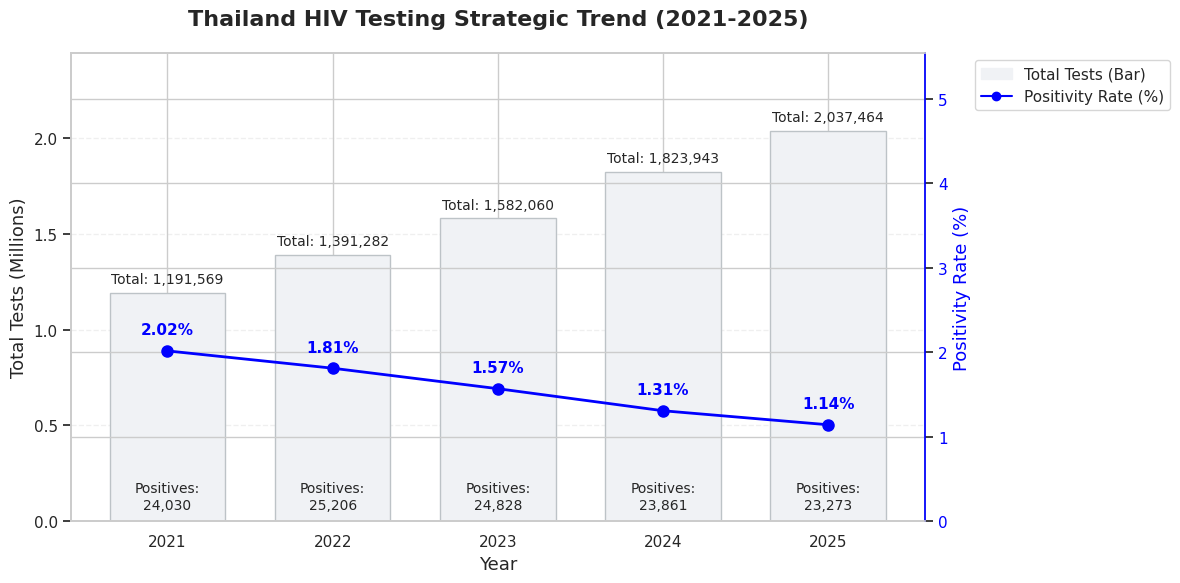

In [23]:
# @title-
yearly_cols = df_long.columns[11:]
yearly_totals = df_long.groupby('year')[yearly_cols].sum()
yearly_totals.index = yearly_totals.index.astype(int)
yearly_totals['Positivity Rate'] = (yearly_totals['positive'] / yearly_totals['test']) * 100

# สร้างตัวแปรสำหรับ Plot (หารล้าน)
test_total_m = yearly_totals['test'] / 1e6

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. วาดกราฟแท่ง (Total Tests)
ax1.bar(yearly_totals.index, test_total_m,
        color='#f0f2f5', label='Total Tests', edgecolor='#bdc3c7', width=0.7)

# ปรับแต่งแกน Y ฝั่งซ้าย
ax1.set_xlabel('Year', fontsize=13, fontweight='normal')
ax1.set_ylabel('Total Tests (Millions)', fontsize=13, fontweight='normal')
ax1.set_xticks(yearly_totals.index)
ax1.set_ylim(0, test_total_m.max() * 1.2) # เผื่อที่ด้านบนสำหรับ Label

# 2. สร้างแกน Y ที่สอง สำหรับ Positivity Rate
ax2 = ax1.twinx()
ax2.plot(yearly_totals.index, yearly_totals['Positivity Rate'],
         marker='o', markersize=8, label='Positivity Rate', color='#0000FF', linewidth=2) #linestyle='--', #2c3e50

# ปรับแต่งแกน Y ฝั่งขวา
ax2.set_ylabel('Positivity Rate (%)', fontsize=13, color='#0000FF', fontweight='normal') #2c3e50
ax2.set_ylim(0, yearly_totals['Positivity Rate'].max() * 2.75) # ปรับให้เส้นกราฟอยู่ช่วงกลาง
#ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#0000FF')
ax2.spines['right'].set_color('#0000FF')

# 4. การตกแต่ง (Styling)
plt.title('Thailand HIV Testing Strategic Trend (2021-2025)',
          fontsize=16, pad=20, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
#ax1.spines['top'].set_visible(False)
#ax2.spines['top'].set_visible(False)

# 5. ใส่ตัวเลขกำกับ (Annotations)
# ตัวเลข Total Tests (ด้านบนแท่ง)
for x, y_m, y_real in zip(yearly_totals.index, test_total_m, yearly_totals['test']):
    ax1.text(x, y_m + 0.05, f'Total: {int(y_real):,}',
             ha='center', fontsize=10, fontweight='normal') #, color='#7f8c8d'

# ตัวเลข Positive Cases (วางไว้ที่ฐานแท่ง)
for x in yearly_totals.index:
    pos_val = int(yearly_totals.loc[x, 'positive'])
    ax1.text(x, 0.05, f'Positives:\n{pos_val:,}',
             ha='center', va='bottom', fontsize=10, fontweight='normal') #, color='#d35400'

# ตัวเลข % (บนจุดของเส้น)
for x, y in zip(yearly_totals.index, yearly_totals['Positivity Rate']):
    ax2.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0, 12),
                 ha='center', fontweight='bold', color='#0000FF', fontsize=11)

# 6. สร้าง Legend
grey_patch = mpatches.Patch(color='#f0f2f5', label='Total Tests (Bar)')
blue_line = mlines.Line2D([], [], color='#0000FF', marker='o', label='Positivity Rate (%)') #linestyle='--', #2c3e50

ax1.legend(handles=[grey_patch, blue_line], loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True)

plt.tight_layout()
plt.savefig('f1_thailand_hiv_testing_trend', bbox_inches='tight')
plt.show()

ตีความได้ 2 แบบ  
1. โฟกัสถูกกลุ่มไหม  
อธิบายเรื่องเพศ และกลุ่มประชากร ให้ recommendation ว่าควรโฟกัสกลุ่ม ผญ. ยังไง
2. กักกันโรคได้ดีแล้ว เพราะจำนวนผู้ติดเชื้อไม่ได้เพิ่มขึ้นตามจำนวนผู้ตรวจ  
อธิบายเชิงพื้นที่ ว่าภาคไหนเสี่ยงไม่เสี่ยง ลงรายจังหวัด แล้วจบด้วยการโฟกัส high yield.. ให้รายชื่อจังหวัดที่ต้องโฟกัส และทำ resource reallocation

---
## ข้อ 1: ภาพรวมและช่องว่างของข้อมูล (Overall Positivity Rate & KPs vs Other)
ตรวจสอบอัตราการตรวจพบเชื้อในภาพรวม และเปรียบเทียบระหว่างกลุ่ม Key Populations (KPs) และกลุ่มคนทั่วไป (Other)

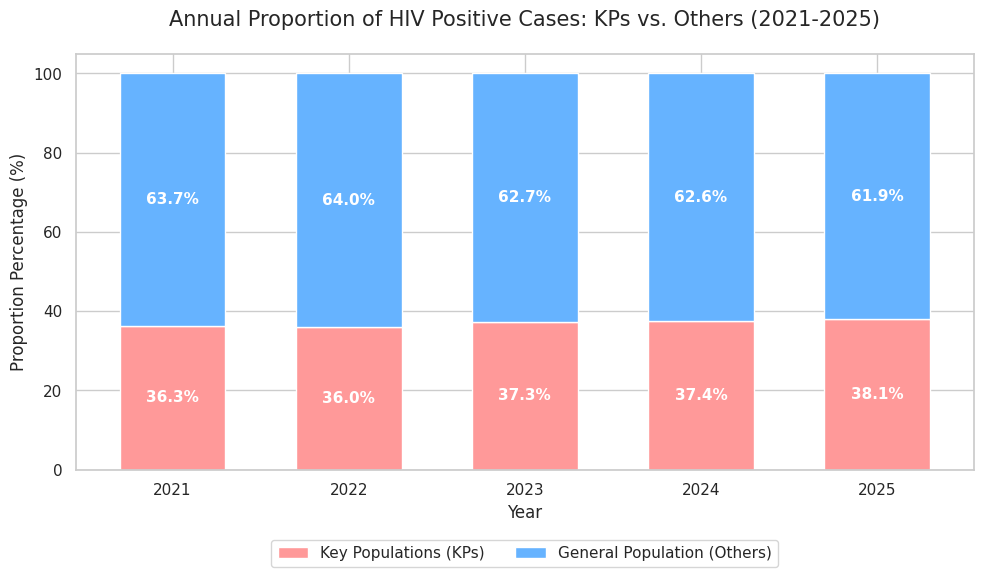

In [24]:
# 1. จัดกลุ่มข้อมูลตามปี และรวมยอดผู้ติดเชื้อ KPs กับ Others
yearly_data = df.groupby('year')[['positive_all_kps', 'positive_others']].sum()

# 2. คำนวณเป็นสัดส่วนเปอร์เซ็นต์ (Normalization to 100%)
yearly_prop = yearly_data.div(yearly_data.sum(axis=1), axis=0) * 100

# 3. สร้างกราฟ Stacked Bar Chart
ax = yearly_prop.plot(kind='bar',
                      stacked=True,
                      figsize=(10, 6),
                      color=['#ff9999', '#66b3ff'],
                      width=0.6)

# --- ส่วนของการเปลี่ยนรายละเอียดกราฟเป็นภาษาอังกฤษ (Graph Details in English) ---

# ตั้งชื่อหัวข้อและแกน
plt.title('Annual Proportion of HIV Positive Cases: KPs vs. Others (2021-2025)', fontsize=15, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion Percentage (%)', fontsize=12)

# ปรับชื่อ Legend (คำอธิบายสัญลักษณ์)
plt.legend(['Key Populations (KPs)', 'General Population (Others)'],
           loc='upper center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=2)

# ใส่ตัวเลข % กำกับบนแท่งกราฟ
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0: # แสดงตัวเลขเฉพาะเมื่อมีค่ามากกว่า 0
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=11,
                fontweight='bold',
                color='white')

plt.xticks(rotation=0) # ให้ปีแสดงผลในแนวตั้งปกติ
plt.tight_layout()
plt.savefig('f2_proportion_of_hiv_positive_case', bbox_inches='tight')
plt.show()

จาก Proportion จะเห็นได้ว่าในแต่ละปีสัดส่วนของทั้งสองไม่มีการเปลี่ยนแปลงเลย


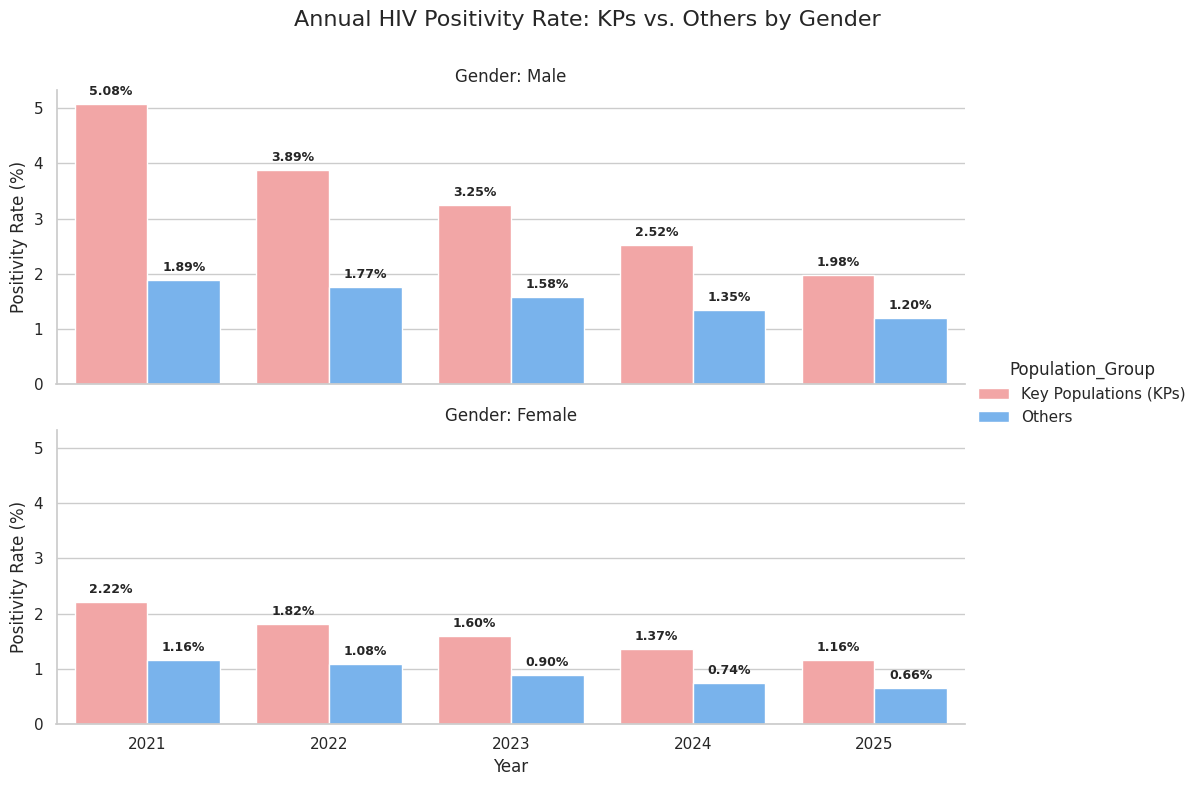

In [34]:
# 1. เตรียมข้อมูล Positivity Rate แยกตามปี เพศ และกลุ่มประชากร
# จัดกลุ่มข้อมูลรายปีและเพศ
yearly_gender_summary = df.groupby(['year', 'sex']).sum().reset_index()

# สร้าง DataFrame ใหม่สำหรับพล็อตโดยคำนวณ Rate แยกเป็น KPs และ Others
rows = []
for _, row in yearly_gender_summary.iterrows():
    # คำนวณของกลุ่ม KPs
    kp_rate = (row['positive_all_kps'] / row['test_all_kps'] * 100) if row['test_all_kps'] > 0 else 0
    rows.append({'Year': row['year'], 'Gender': row['sex'].capitalize(),
                 'Population_Group': 'Key Populations (KPs)', 'Positivity_Rate': kp_rate})

    # คำนวณของกลุ่ม Others
    others_rate = (row['positive_others'] / row['test_others'] * 100) if row['test_others'] > 0 else 0
    rows.append({'Year': row['year'], 'Gender': row['sex'].capitalize(),
                 'Population_Group': 'Others', 'Positivity_Rate': others_rate})

plot_df = pd.DataFrame(rows)

# 2. สร้างกราฟแยกตามเพศเป็น 2 บรรทัด (FacetGrid)
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df,
    x='Year',
    y='Positivity_Rate',
    hue='Population_Group',
    row='Gender',
    row_order=['Male', 'Female'], # <--- เพิ่มบรรทัดนี้เพื่อกำหนดให้ Male ขึ้นก่อน
    kind='bar',
    palette=['#ff9999', '#66b3ff'],
    height=4,
    aspect=2.5
)

# --- Graph Details in English ---

# ตั้งชื่อแกนและหัวข้อย่อย
g.set_axis_labels("Year", "Positivity Rate (%)")
g.set_titles("Gender: {row_name}")

# ใส่ตัวเลข % กำกับบนแท่งกราฟ
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}%',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=9, fontweight='bold')

# ปรับระยะห่างด้านบนไม่ให้ชื่อกราฟหลักทับกับกราฟย่อย
plt.subplots_adjust(top=0.88)
g.fig.suptitle('Annual HIV Positivity Rate: KPs vs. Others by Gender', fontsize=16)
plt.savefig('f3_anuual_hiv_positivity_rate_by_gender', bbox_inches='tight')
plt.show()

ดูที่อัตราการตรวจพบเชื้อหรือ Positivity Rate จะพบว่าทุกกลุ่มประชากรมีแนวโน้มลดลงอย่างต่อเนื่องในช่วง 5 ปีที่ผ่านมา โดยเฉพาะกลุ่มผู้ชายที่เป็นกลุ่มเสี่ยงหลัก (Male KPs) อัตราลดลงจาก 5.08% เหลือเพียง 1.98% และกลุ่มอื่นๆก็ลดลงมาตามลำดับ ซึ่งในมุมมองสถิติเบื้องต้นอาจดูเหมือนว่าสถานการณ์การระบาดกำลังคลี่คลายลง

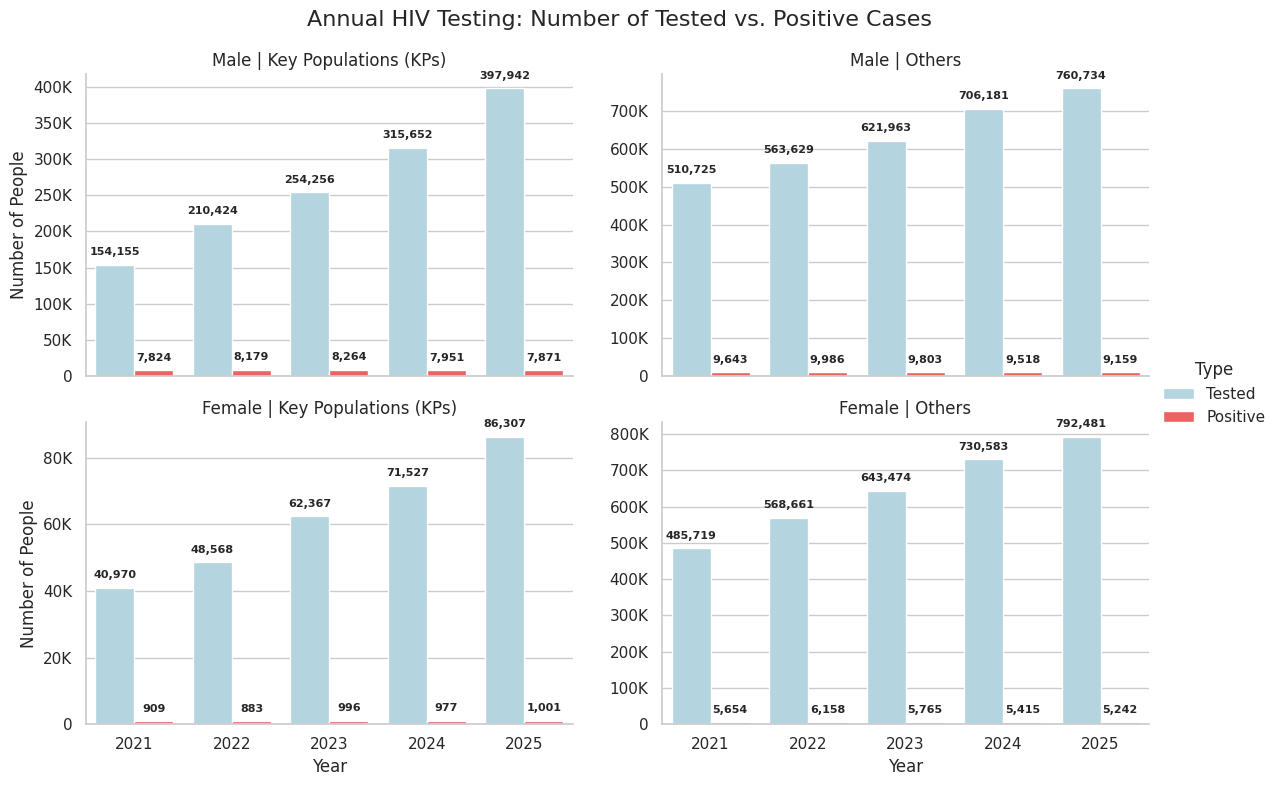

In [35]:
# 1. เตรียมข้อมูลจำนวนคน (Counts) แยกตามปี เพศ และกลุ่มประชากร
yearly_gender_summary = df.groupby(['year', 'sex']).sum().reset_index()

rows = []
for _, row in yearly_gender_summary.iterrows():
    gender = row['sex'].capitalize()
    year = row['year']

    # ข้อมูลกลุ่ม KPs
    rows.append({'Year': year, 'Gender': gender, 'Population': 'Key Populations (KPs)', 'Type': 'Tested', 'Count': row['test_all_kps']})
    rows.append({'Year': year, 'Gender': gender, 'Population': 'Key Populations (KPs)', 'Type': 'Positive', 'Count': row['positive_all_kps']})

    # ข้อมูลกลุ่ม Others
    rows.append({'Year': year, 'Gender': gender, 'Population': 'Others', 'Type': 'Tested', 'Count': row['test_others']})
    rows.append({'Year': year, 'Gender': gender, 'Population': 'Others', 'Type': 'Positive', 'Count': row['positive_others']})

plot_df = pd.DataFrame(rows)

# 2. สร้างกราฟแยกตามเพศ (Row) และกลุ่มประชากร (Col)
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df,
    x='Year',
    y='Count',
    hue='Type',
    row='Gender',
    col='Population',
    row_order=['Male', 'Female'],
    kind='bar',
    palette=['#add8e6', '#ff4d4d'], # สีฟ้าอ่อน (Tested) และ สีแดง (Positive)
    height=4,
    aspect=1.5,
    sharey=False # แยกสเกลแกน Y เพราะจำนวนคนตรวจกับคนติดอาจต่างกันมาก
)

# --- ปรับแต่งรายละเอียดกราฟ ---
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K' if x >= 1000 else f'{int(x)}'))

g.set_axis_labels("Year", "Number of People")
g.set_titles("{row_name} | {col_name}")

# ใส่ตัวเลขจำนวนคนกำกับบนแท่งกราฟ
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=8, fontweight='bold')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Annual HIV Testing: Number of Tested vs. Positive Cases', fontsize=16)
plt.savefig('f4_anuual_hiv_tested_vs_positive_case', bbox_inches='tight')
plt.show()

เมื่อเราขยายจาก % ในกลุ่มต่างๆจะดูเหมือนลดลง แต่เมื่อดูที่ จำนวนคนติดเชื้อจริง (Positive) กลับพบว่าตัวเลขคงที่อยู่ที่ประมาณเดิมคนต่อปี ไม่ได้ลดลงเลย นั่นหมายความว่า เรายังเข้าไม่ถึงต้นตอของการแพร่ระบาด เราแค่ตรวจคนเยอะขึ้นจนทำให้สัดส่วนเปอร์เซ็นต์มันดูน้อยลงเท่านั้น จากแท่งสีฟ้าพบว่าจำนวนคนตรวจเยอะขึ้น โดยเฉพาะกลุ่ม (Others) ทั้งชายและหญิงที่เพิ่มขึ้นจากประมาณ 5 แสนเป็นประมาณ 7 แสนครั้งต่อปีแต่จำนวนก็เท่าเดิมแม้กลุ่ม Others จะดูเหมือนเสี่ยงน้อย แต่ในแง่ จำนวนคน มีคนติดเชื้อรวมมากกว่ากลุ่ม KPs สิ่งนี้ชี้ให้เห็นว่าปัญหาไม่ได้จำกัดอยู่แค่กลุ่มเสี่ยง แต่กระจายตัวอยู่ในประชากรทั่วไปในปริมาณที่มากกว่า ถ้าเราสามารถนำ Other มาหาเป็น key pop ได้เราจะสามารถลด workload ของคนตรวจและสามารถเจาะจงได้ถูกจุดยิ่งขึ้น
โดยเราจะ focus ไปที่รายจังหวัดเพื่อนำหา key pop เพิ่มเติมว่าจังหวัดไหนควรที่จะโฟกัสมากขึ้น

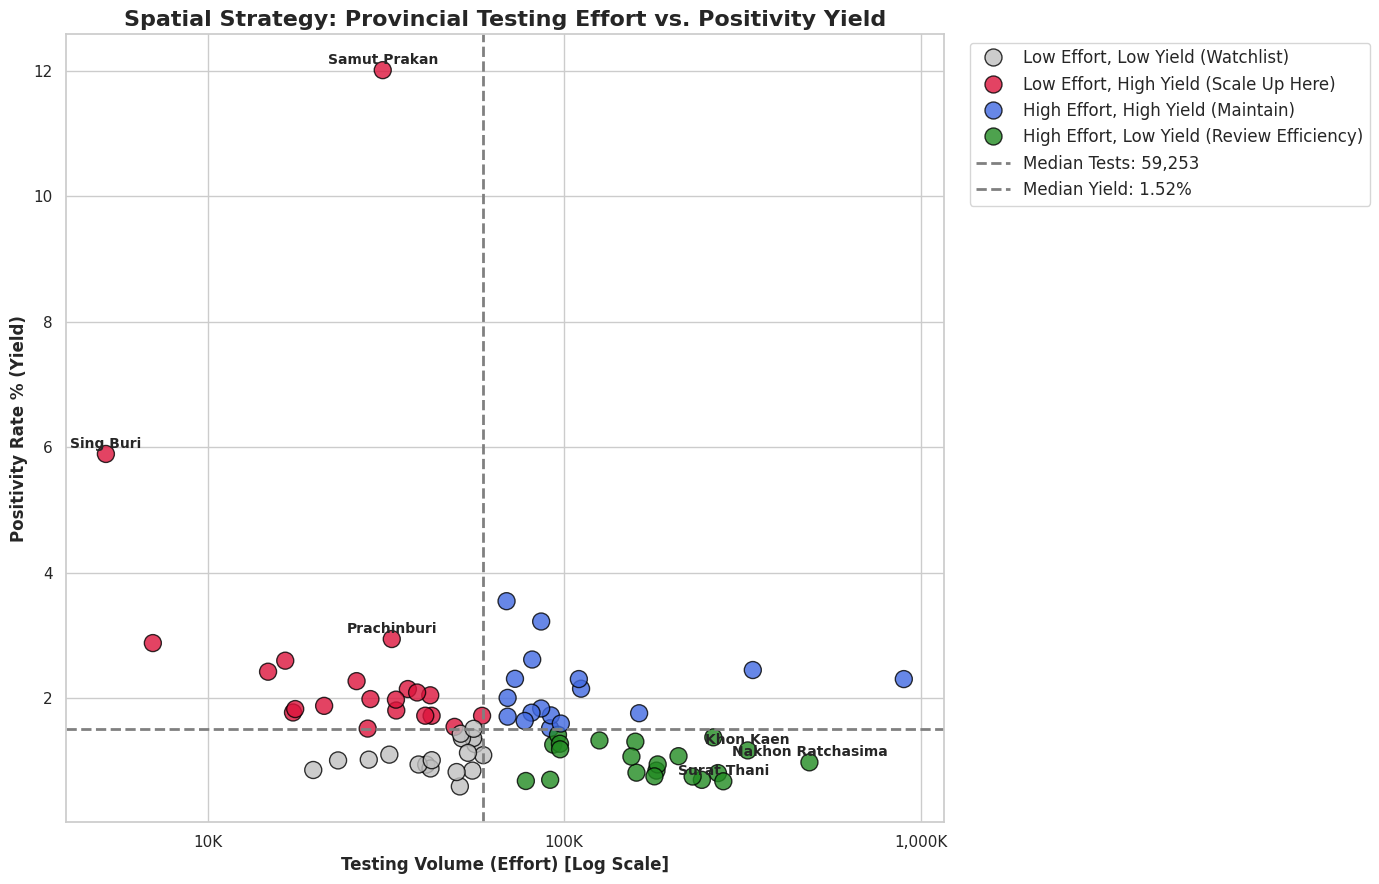

In [36]:
# Aggregate by Province
provincial_data = df_long.groupby('province')[['test', 'positive']].sum().reset_index()
provincial_data = provincial_data[provincial_data['test'] > 0]
provincial_data['yield_rate'] = (provincial_data['positive'] / provincial_data['test']) * 100

median_test = provincial_data['test'].median()
median_yield = provincial_data['yield_rate'].median()

def categorize_province(row):
    if row['test'] > median_test and row['yield_rate'] < median_yield:
        return 'High Effort, Low Yield (Review Efficiency)'
    elif row['test'] < median_test and row['yield_rate'] > median_yield:
        return 'Low Effort, High Yield (Scale Up Here)'
    elif row['test'] >= median_test and row['yield_rate'] >= median_yield:
        return 'High Effort, High Yield (Maintain)'
    else:
        return 'Low Effort, Low Yield (Watchlist)'

provincial_data['Quadrant'] = provincial_data.apply(categorize_province, axis=1)

plt.figure(figsize=(14, 9))
sns.scatterplot(
    data=provincial_data,
    x='test',
    y='yield_rate',
    hue='Quadrant',
    palette={
        'High Effort, Low Yield (Review Efficiency)': 'forestgreen',
        'Low Effort, High Yield (Scale Up Here)': 'crimson',
        'High Effort, High Yield (Maintain)': 'royalblue',
        'Low Effort, Low Yield (Watchlist)': 'silver'
    },
    s=150, alpha=0.8, edgecolor='black'
)

plt.axvline(median_test, color='gray', linestyle='--', linewidth=2, label=f'Median Tests: {median_test:,.0f}')
plt.axhline(median_yield, color='gray', linestyle='--', linewidth=2, label=f'Median Yield: {median_yield:.2f}%')

top_scale_up = provincial_data[provincial_data['Quadrant'] == 'Low Effort, High Yield (Scale Up Here)'].sort_values('yield_rate', ascending=False).head(3)
top_review = provincial_data[provincial_data['Quadrant'] == 'High Effort, Low Yield (Review Efficiency)'].sort_values('test', ascending=False).head(3)

for _, row in pd.concat([top_scale_up, top_review]).iterrows():
    plt.text(row['test'], row['yield_rate'] + 0.1, row['province'], fontsize=10, fontweight='bold', ha='center')

plt.xscale('log')
# ดึง Axes ปัจจุบันมาปรับ Format
ax = plt.gca()

# ปรับ Format แกน X ด้วย Lambda ตามเงื่อนไขที่คุณต้องการ
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K' if x >= 1000 else f'{int(x)}')
)

# บังคับให้แสดง Ticks ให้ครอบคลุมช่วงข้อมูล (ป้องกันเลขหายตอนทำ Log)
import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))

plt.title('Spatial Strategy: Provincial Testing Effort vs. Positivity Yield', fontsize=16, fontweight='bold')
plt.xlabel('Testing Volume (Effort) [Log Scale]', fontweight='bold')
plt.ylabel('Positivity Rate % (Yield)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.savefig('f5_spatial_strategy_effort_vs_yield', bbox_inches='tight')
plt.show()

**เปลี่ยนสีเส้น median ให้แตกต่างกัน**  



**Strategic Implication:**  
1. Scale Up: Increase budgets and ACF tools in the Red Quadrant provinces. They have high yields and room to grow testing volume.  
2. Review Efficiency: Investigate the Green Quadrant provinces. Despite massive testing, yields are exceptionally low—suggesting untargeted 'blind' screening.

โดยตรวจสอบรายชื่อจังหวัดเพิ่มเติมจากตาราง

In [28]:
# 1. ตารางกลุ่ม Low Effort, High Yield (Scale Up Here)
scale_up_table = provincial_data[provincial_data['Quadrant'] == 'Low Effort, High Yield (Scale Up Here)'][['province', 'test', 'positive', 'yield_rate']]
scale_up_table = scale_up_table.sort_values('yield_rate', ascending=False)

# 2. ตารางกลุ่ม High Effort, Low Yield (Review Efficiency)
review_efficiency_table = provincial_data[provincial_data['Quadrant'] == 'High Effort, Low Yield (Review Efficiency)'][['province', 'test', 'positive', 'yield_rate']]
review_efficiency_table = review_efficiency_table.sort_values('test', ascending=False)

#selected_provincial_data = pd.concat([scale_up_table, review_efficiency_table], ignore_index=True)
selected_provincial_data = scale_up_table
selected_provincial_data = selected_provincial_data['province'].unique()
selected_provincial_data = list(selected_provincial_data)
# แสดงผล
print("ตาราง: Low Effort, High Yield")
display(scale_up_table.head(10))

print("\nตาราง: High Effort, Low Yield")
display(review_efficiency_table.head(10))

ตาราง: Low Effort, High Yield


,province,test,positive,yield_rate
56,Samut Prakan,30954.0,3718.0,12.011372
61,Sing Buri,5173.0,305.0,5.895998
48,Prachinburi,32813.0,967.0,2.947003
58,Samut Songkhram,7007.0,202.0,2.882831
1,Ang Thong,16485.0,429.0,2.602366
70,Trat,14753.0,358.0,2.426625
46,Phrae,26139.0,595.0,2.276292
34,Nong Khai,36409.0,783.0,2.150567
54,Sa Kaeo,38654.0,810.0,2.095514
18,Lampang,42077.0,863.0,2.051002



ตาราง: High Effort, Low Yield


,province,test,positive,yield_rate
28,Nakhon Ratchasima,487757.0,4792.0,0.982456
16,Khon Kaen,327448.0,3840.0,1.172705
66,Surat Thani,279602.0,1903.0,0.680610
10,Chiang Rai,270102.0,2191.0,0.811175
9,Chiang Mai,262097.0,3620.0,1.381168
44,Phitsanulok,243425.0,1712.0,0.703297
53,Roi Et,229275.0,1734.0,0.756297
71,Ubon Ratchathani,209316.0,2262.0,1.080663
30,Nakhon Si Thammarat,182943.0,1737.0,0.949476
23,Maha Sarakham,181524.0,1544.0,0.850576


Shapefile columns: ['name', 'geometry']
Province name sample: ['Mae Hong Son', 'Chumphon', 'Nakhon Si Thammarat', 'Phuket', 'Phangnga', 'Ranong', 'Surat Thani', 'Krabi', 'Phatthalung', 'Satun']
All provinces matched (Female)


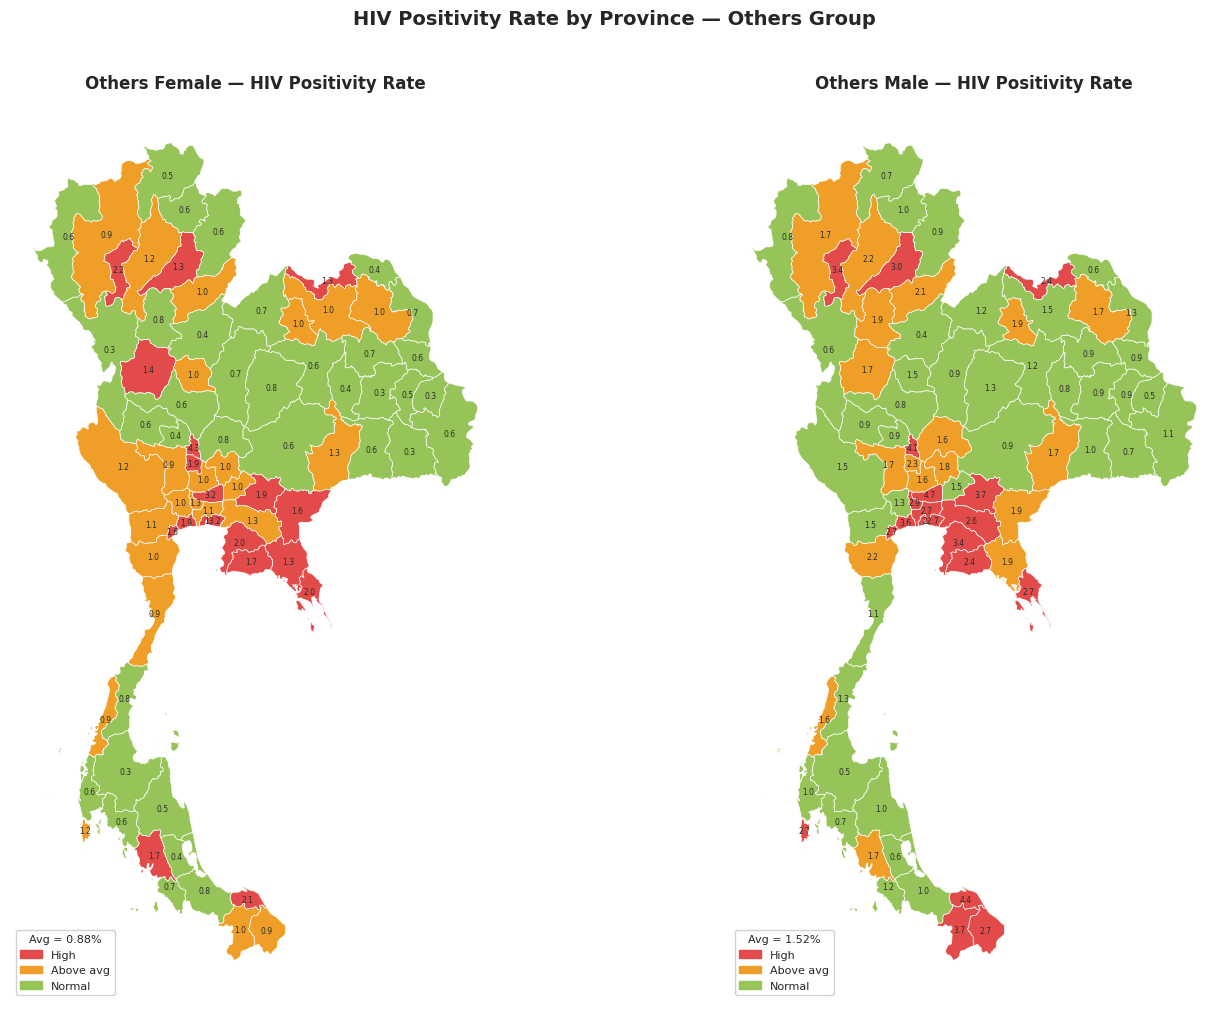

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import geopandas as gpd
import pandas as pd
import numpy as np

# ── 1. Load Thailand shapefile from GitHub ────────────────────────────────────
# Source: GADM Thailand level-1 (province), no install needed — reads directly
url = 'https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json'
gdf = gpd.read_file(url)

print("Shapefile columns:", gdf.columns.tolist())
print("Province name sample:", gdf['name'].head(10).tolist())

# ── 2. Filter Others Female and Others Male ───────────────────────────────────
mask_of = (
    (df_long['sex'].str.strip().str.lower() == 'female') &
    (~df_long['group'].str.strip().str.lower().str.contains('kp|key'))
)
mask_om = (
    (df_long['sex'].str.strip().str.lower() == 'male') &
    (~df_long['group'].str.strip().str.lower().str.contains('kp|key'))
)

df_of = df_long[mask_of].copy()
df_om = df_long[mask_om].copy()

# ── 3. Aggregate by province ──────────────────────────────────────────────────
def agg_province(df):
    prov = (
        df.groupby('province', as_index=False)
        .agg(total_pos=('positive', 'sum'), total_test=('test', 'sum'))
    )
    prov['rate'] = (prov['total_pos'] / prov['total_test'] * 100).round(3)
    return prov

prov_f = agg_province(df_of)
prov_m = agg_province(df_om)

avg_f = df_of['positive'].sum() / df_of['test'].sum() * 100
avg_m = df_om['positive'].sum() / df_om['test'].sum() * 100

# ── 4. Match province names: data -> shapefile ────────────────────────────────
# *** ถ้า merge แล้วได้ NaN เยอะ ให้ print ดู mismatch ด้านล่าง ***
name_map = {
    'Phangnga'          : 'Phang Nga',
    'Lop Buri'          : 'Lopburi',
    'Prachin Buri'      : 'Prachinburi',
    'Bangkok Metropolis': 'Bangkok',
    'Si Sa Ket'         : 'Sisaket',
    'Chon Buri'         : 'Chonburi',
    'Buri Ram'          : 'Buriram',
    'Nong Bua Lam Phu'  : 'Nong Bua Lamphu',
}
gdf['name'] = gdf['name'].replace(name_map)

gdf_f = gdf.merge(prov_f, left_on='name', right_on='province', how='left')
gdf_m = gdf.merge(prov_m, left_on='name', right_on='province', how='left')

# Debug: check remaining mismatches
no_match_f = gdf_f[gdf_f['rate'].isna()]['name'].tolist()
no_match_m = gdf_m[gdf_m['rate'].isna()]['name'].tolist()
if no_match_f:
    print(f"Still no match (Female): {no_match_f}")
else:
    print("All provinces matched (Female)")

# ── 5. Risk category ──────────────────────────────────────────────────────────
def risk_label(rate, avg):
    if pd.isna(rate):    return 'No data'
    if rate > avg * 1.5: return 'High'
    if rate > avg:       return 'Above avg'
    return 'Normal'

gdf_f['risk'] = gdf_f['rate'].apply(lambda r: risk_label(r, avg_f))
gdf_m['risk'] = gdf_m['rate'].apply(lambda r: risk_label(r, avg_m))

color_map = {
    'High'      : '#E24B4A',
    'Above avg' : '#EF9F27',
    'Normal'    : '#97C459',
}

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

def draw_map(ax, gdf_plot, avg, title):
    for risk, color in color_map.items():
        subset = gdf_plot[gdf_plot['risk'] == risk]
        if len(subset):
            subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)

    # annotate rate on each province
    for _, row in gdf_plot.iterrows():
        if pd.notna(row.get('rate')):
            cx = row.geometry.centroid.x
            cy = row.geometry.centroid.y
            ax.annotate(
                f"{row['rate']:.1f}",
                xy=(cx, cy),
                fontsize=5.5,
                ha='center', va='center',
                color='#2C2C2A',
            )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_axis_off()

    # mini legend inside map
    patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
    ax.legend(handles=patches, loc='lower left', fontsize=8,
              framealpha=0.9, title=f'Avg = {avg:.2f}%', title_fontsize=8)

draw_map(ax1, gdf_f, avg_f, 'Others Female — HIV Positivity Rate')
draw_map(ax2, gdf_m, avg_m, 'Others Male — HIV Positivity Rate')

plt.suptitle('HIV Positivity Rate by Province — Others Group',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('f6_geospatial_intelligence', bbox_inches='tight')
plt.show()

---
## ข้อ 2: การระบุกลุ่มประชากรแฝง (Hidden KPs)
เปรียบเทียบการกระจายตัวของผู้ติดเชื้อแยกตามเพศ ดูความผิดปกติในกลุ่ม "Other" ว่าสามารถ focus group ไหนเพิ่มในกลุ่ม other ได้บ้าง

Others Female avg: 0.877%  ->  21 provinces above avg
Others Male   avg: 1.521%  ->  19 provinces above avg


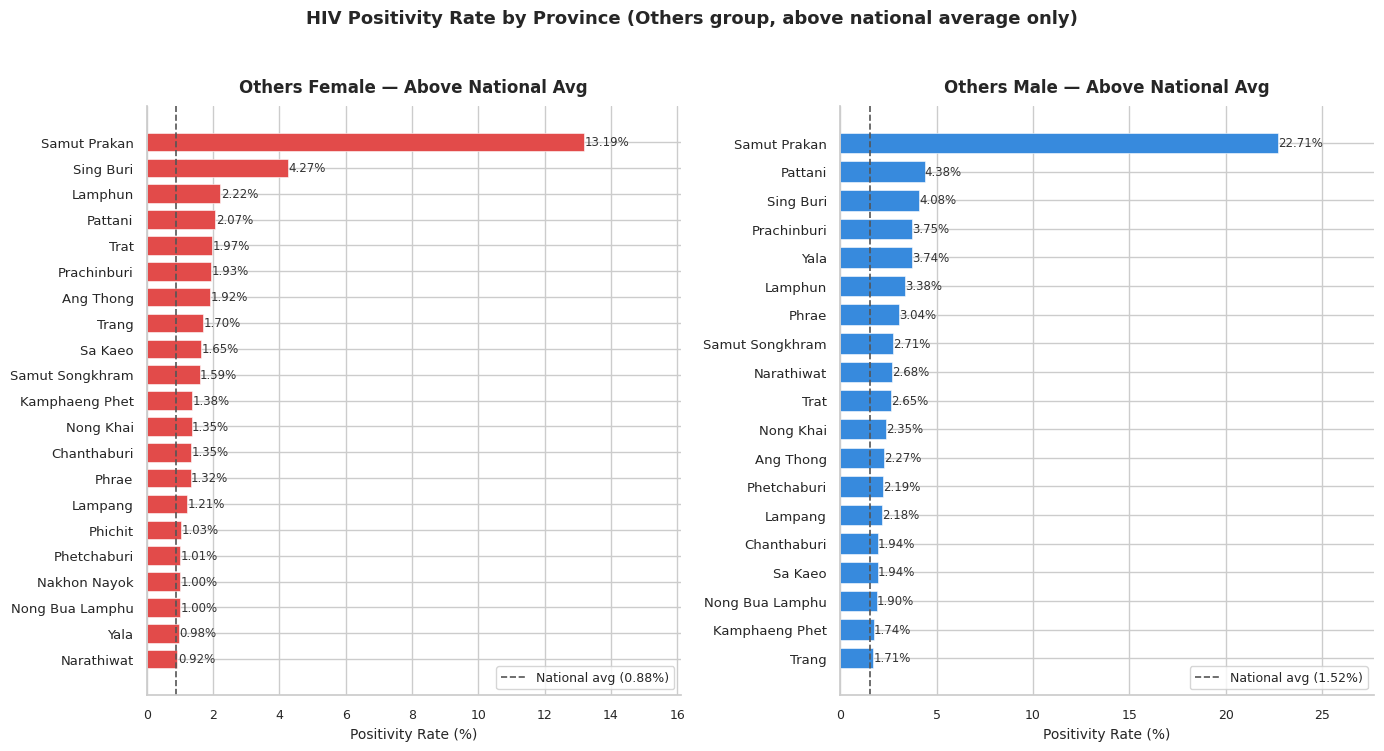


Top 10 Others Female:


,Province,Rate (%),Positives,Tested
Rank,,,,
1,Samut Prakan,13.193000,940.000000,7125.000000
2,Sing Buri,4.267000,80.000000,1875.000000
3,Lamphun,2.222000,153.000000,6885.000000
4,Pattani,2.067000,59.000000,2855.000000
5,Trat,1.973000,120.000000,6082.000000
6,Prachinburi,1.934000,256.000000,13235.000000
7,Ang Thong,1.917000,118.000000,6157.000000
8,Trang,1.704000,171.000000,10037.000000
9,Sa Kaeo,1.646000,271.000000,16461.000000



Top 10 Others Male:


,Province,Rate (%),Positives,Tested
Rank,,,,
1,Samut Prakan,22.709000,1722.000000,7583.000000
2,Pattani,4.375000,90.000000,2057.000000
3,Sing Buri,4.077000,89.000000,2183.000000
4,Prachinburi,3.745000,474.000000,12657.000000
5,Yala,3.744000,59.000000,1576.000000
6,Lamphun,3.381000,267.000000,7897.000000
7,Phrae,3.042000,384.000000,12623.000000
8,Samut Songkhram,2.711000,80.000000,2951.000000
9,Narathiwat,2.678000,154.000000,5750.000000


In [38]:
# @title
import matplotlib.pyplot as plt

# ── 1. Filter Others Female and Others Male ───────────────────────────────────
mask_of = (
    (df_long['sex'].str.strip().str.lower() == 'female') &
    (~df_long['group'].str.strip().str.lower().str.contains('kp|key'))
)
mask_om = (
    (df_long['sex'].str.strip().str.lower() == 'male') &
    (~df_long['group'].str.strip().str.lower().str.contains('kp|key'))
)

df_of = df_long[mask_of].copy()
df_om = df_long[mask_om].copy()

# ── 2. Aggregate by province ──────────────────────────────────────────────────
def agg_province(df):
    prov = (
        df.groupby('province', as_index=False)
        .agg(total_pos=('positive', 'sum'), total_test=('test', 'sum'))
    )
    prov = prov[prov['province'].isin(selected_provincial_data)].copy() #filter only Red & Green zone
    prov['rate'] = (prov['total_pos'] / prov['total_test'] * 100).round(3)
    return prov

prov_f = agg_province(df_of)
prov_m = agg_province(df_om)

# ── 3. National average & filter above avg only ───────────────────────────────
avg_f = df_of['positive'].sum() / df_of['test'].sum() * 100
avg_m = df_om['positive'].sum() / df_om['test'].sum() * 100

prov_f = prov_f[prov_f['rate'] > avg_f].sort_values('rate', ascending=False).reset_index(drop=True)
prov_m = prov_m[prov_m['rate'] > avg_m].sort_values('rate', ascending=False).reset_index(drop=True)

print(f"Others Female avg: {avg_f:.3f}%  ->  {len(prov_f)} provinces above avg")
print(f"Others Male   avg: {avg_m:.3f}%  ->  {len(prov_m)} provinces above avg")

# ── 4. Plot side by side ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(6, max(len(prov_f), len(prov_m)) * 0.35)))

def draw_bar(ax, prov, avg, color, title):
    bars = ax.barh(prov['province'], prov['rate'],
                   color=color, edgecolor='white', linewidth=0.4, height=0.72)
    ax.invert_yaxis()
    ax.axvline(avg, color='#555', lw=1.2, ls='--', label=f'National avg ({avg:.2f}%)')
    for bar, rate in zip(bars, prov['rate']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{rate:.2f}%', va='center', ha='left', fontsize=8.5, color='#333')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Positivity Rate (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9.5)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_xlim(0, prov['rate'].max() * 1.22)

draw_bar(ax1, prov_f, avg_f, '#E24B4A', 'Others Female — Above National Avg')
draw_bar(ax2, prov_m, avg_m, '#378ADD', 'Others Male — Above National Avg')

plt.suptitle('HIV Positivity Rate by Province (Others group, above national average only)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('f7_hiv_positive_rate_by_province_above_avg', bbox_inches='tight')
plt.show()

# ── 5. Top 10 tables ──────────────────────────────────────────────────────────
def top10_table(prov, label):
    return (
        prov[['province', 'rate', 'total_pos', 'total_test']]
        .head(10)
        .rename(columns={
            'province'  : 'Province',
            'rate'      : 'Rate (%)',
            'total_pos' : 'Positives',
            'total_test': 'Tested',
        })
        .assign(Rank=range(1, min(11, len(prov) + 1)))
        .set_index('Rank')
        .style.background_gradient(subset=['Rate (%)'], cmap='Reds')
        .set_caption(f'Top 10 — {label}')
    )

print("\nTop 10 Others Female:")
display(top10_table(prov_f, 'Others Female'))

print("\nTop 10 Others Male:")
display(top10_table(prov_m, 'Others Male'))

อธิบายเรื่องกลุ่มประชากรแฝงที่อยุ่ในกลุ่มที่ควร scale up ซึ่งแบ่งจังหวัด top 5 ระหว่างกลุ่มประชากรแฝงในผุ้หญิงและผู้ชาย

---
## 🎯 Conclusion: Actionable Recommendations for Policymakers

Based on the **40 visualizations** across four analytical dimensions, we propose **two data-driven recommendations** to optimize Thailand's HIV screening budget:

### 1. 📍 **Reallocate Resources to Under-Screened, High-Yield Provinces**
The spatial efficiency analysis (Section 2) revealed provinces with high positivity rates but comparatively low testing volumes. These provinces are likely **under-served** — meaning many HIV-positive individuals remain undiagnosed. Directing additional screening teams, mobile testing units, and funding to these areas will significantly improve case detection per baht spent.

### 2. 👥 **Scale Up Targeted Testing for the Highest-Risk Key Populations**
The demographic risk profiling (Section 3) showed that certain key populations (e.g., MSM, PWID, TG) exhibit positivity rates many times higher than the general population, yet their share of total tests may not be proportionate to their risk. Increasing dedicated testing programs — especially community-led and peer-driven approaches — for these groups will maximize screening yield and enable earlier treatment initiation.

# จบ

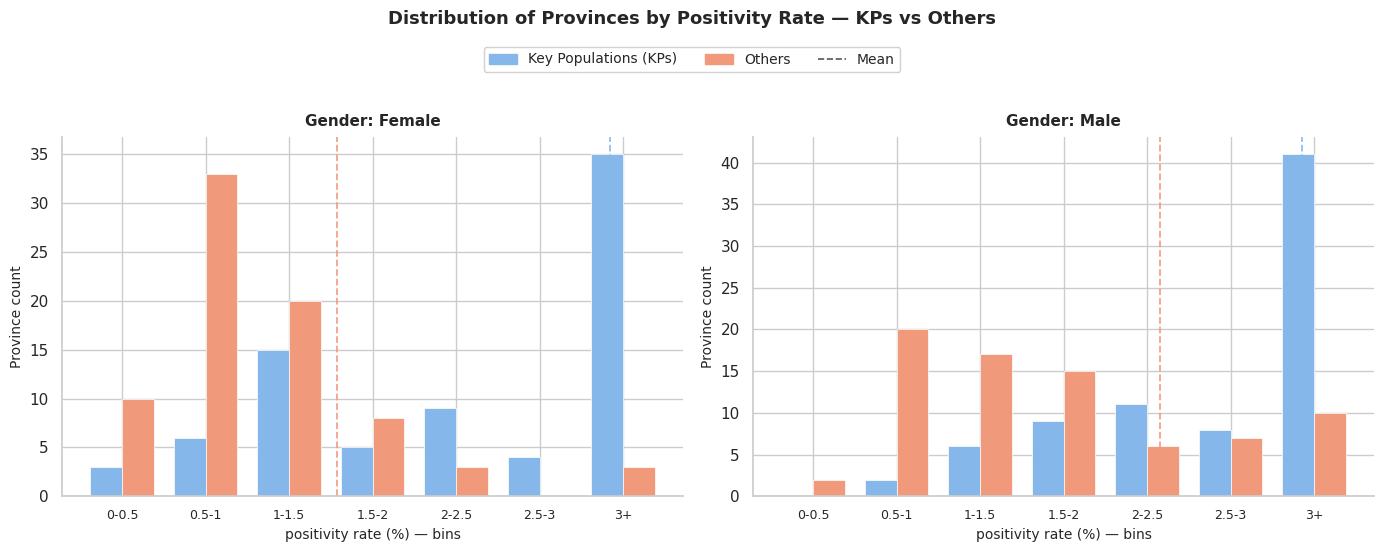

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Filter all 4 groups ────────────────────────────────────────────────────
def filter_group(sex, is_kp):
    mask_sex = df_long['sex'].str.strip().str.lower() == sex
    mask_kp  = df_long['group'].str.strip().str.lower().str.contains('kp|key')
    return df_long[mask_sex & (mask_kp if is_kp else ~mask_kp)].copy()

df_kpf = filter_group('female', True)
df_of  = filter_group('female', False)
df_kpm = filter_group('male',   True)
df_om  = filter_group('male',   False)

# ── 2. Aggregate positivity rate by province ──────────────────────────────────
def prov_rate(df):
    g = df.groupby('province', as_index=False).agg(
        total_pos  = ('positive', 'sum'),
        total_test = ('test',     'sum'),
    )
    g['rate'] = (g['total_pos'] / g['total_test'] * 100).round(3)
    return g['rate'].values

rates_kpf = prov_rate(df_kpf)
rates_of  = prov_rate(df_of)
rates_kpm = prov_rate(df_kpm)
rates_om  = prov_rate(df_om)

# ── 3. Plot function ──────────────────────────────────────────────────────────
def draw_hist(ax, rates_kp, rates_ot, color_kp, color_ot, title):
    max_val = max(rates_kp.max(), rates_ot.max())
    bins    = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, max_val + 0.01]
    labels  = ['0-0.5', '0.5-1', '1-1.5', '1.5-2', '2-2.5', '2.5-3', '3+']

    counts_kp, _ = np.histogram(rates_kp, bins=bins)
    counts_ot, _ = np.histogram(rates_ot, bins=bins)

    x     = np.arange(len(labels))
    width = 0.38

    ax.bar(x - width/2, counts_kp, width, color=color_kp, edgecolor='white', linewidth=0.5)
    ax.bar(x + width/2, counts_ot, width, color=color_ot, edgecolor='white', linewidth=0.5)

    # mean lines (position within x-axis bins)
    for avg, offset, color in [
        (rates_kp.mean(), -width/2, color_kp),
        (rates_ot.mean(),  width/2, color_ot),
    ]:
        bin_idx = min(np.searchsorted(bins[1:], avg), len(labels) - 1)
        x_pos   = bin_idx + (avg - bins[bin_idx]) / (bins[bin_idx+1] - bins[bin_idx]) + offset
        ax.axvline(x_pos, color=color, lw=1.3, ls='--', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel('positivity rate (%) — bins', fontsize=10)
    ax.set_ylabel('Province count', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.get_major_locator().set_params(integer=True)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

draw_hist(ax1, rates_kpf, rates_of,  '#85B7EB', '#F0997B', 'Gender: Female')
draw_hist(ax2, rates_kpm, rates_om,  '#85B7EB', '#F0997B', 'Gender: Male')

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color='#85B7EB', label='Key Populations (KPs)'),
        plt.Rectangle((0,0),1,1, color='#F0997B', label='Others'),
        plt.Line2D([0],[0], color='#555', ls='--', lw=1.2, label='Mean'),
    ],
    loc='upper center', ncol=3, fontsize=10, framealpha=0.9,
    bbox_to_anchor=(0.5, 1.04)
)
fig.suptitle(
    'Distribution of Provinces by Positivity Rate — KPs vs Others',
    fontsize=13, fontweight='bold', y=1.10
)

plt.tight_layout()
plt.savefig('histogram_kp_vs_others_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

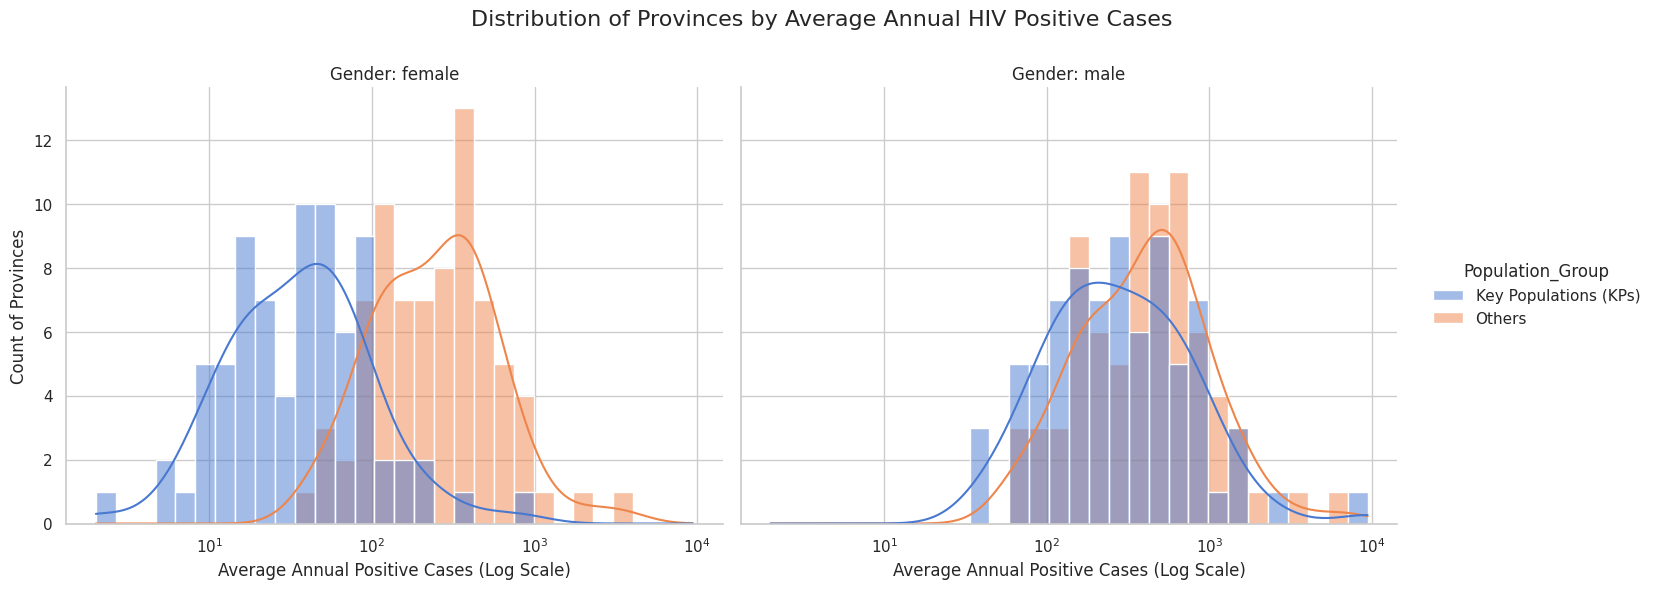

In [32]:
# 1. รวมข้อมูลด้วยค่า Sum เพื่อหาค่าเฉลี่ยต่อปีของแต่ละจังหวัด
# ขั้นตอนนี้สำคัญมาก: จะทำให้ 1 จังหวัด มี 1 record ต่อ 1 เพศ (ป้องกันการนับซ้ำ 3 ปี)
df_avg = df.groupby(['province', 'sex'])[['positive_all_kps', 'positive_others']].sum().reset_index()

# 2. ปรับรูปแบบข้อมูลเป็น Long Format สำหรับ Seaborn
df_melted = df_avg.melt(
    id_vars=['province', 'sex'],
    value_vars=['positive_all_kps', 'positive_others'],
    var_name='Population_Group',
    value_name='Positive_Count'
)

# เปลี่ยนชื่อกลุ่มประชากรเป็นภาษาอังกฤษ
df_melted['Population_Group'] = df_melted['Population_Group'].replace({
    'positive_all_kps': 'Key Populations (KPs)',
    'positive_others': 'Others'
})

# 3. สร้างกราฟ Histogram พร้อม Log Scale
# log_scale=True จะช่วยกระจายข้อมูลที่กระจุกตัวอยู่ที่ 0-10 ให้ดูง่ายขึ้น
sns.set_theme(style="whitegrid")
g = sns.displot(
    data=df_melted,
    x='Positive_Count',
    hue='Population_Group',
    col='sex',
    kind='hist',
    kde=True,        # แสดงเส้นขอบเขตความหนาแน่น
    log_scale=True,  # ใช้มาตราส่วน Logarithm เพื่อขยายช่วงตัวเลขน้อยๆ
    palette='muted',
    height=6,
    aspect=1.2,
    bins=30
)

# --- ส่วนของการเปลี่ยนรายละเอียดกราฟเป็นภาษาอังกฤษ (Graph Details in English) ---

# ตั้งชื่อแกน X และ แกน Y
g.set_axis_labels("Average Annual Positive Cases (Log Scale)", "Count of Provinces")

# ตั้งชื่อหัวข้อกราฟย่อย
g.set_titles("Gender: {col_name}")

# ปรับตำแหน่งเพื่อใส่หัวข้อหลัก
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribution of Provinces by Average Annual HIV Positive Cases', fontsize=16)

# แสดงผล
plt.show()

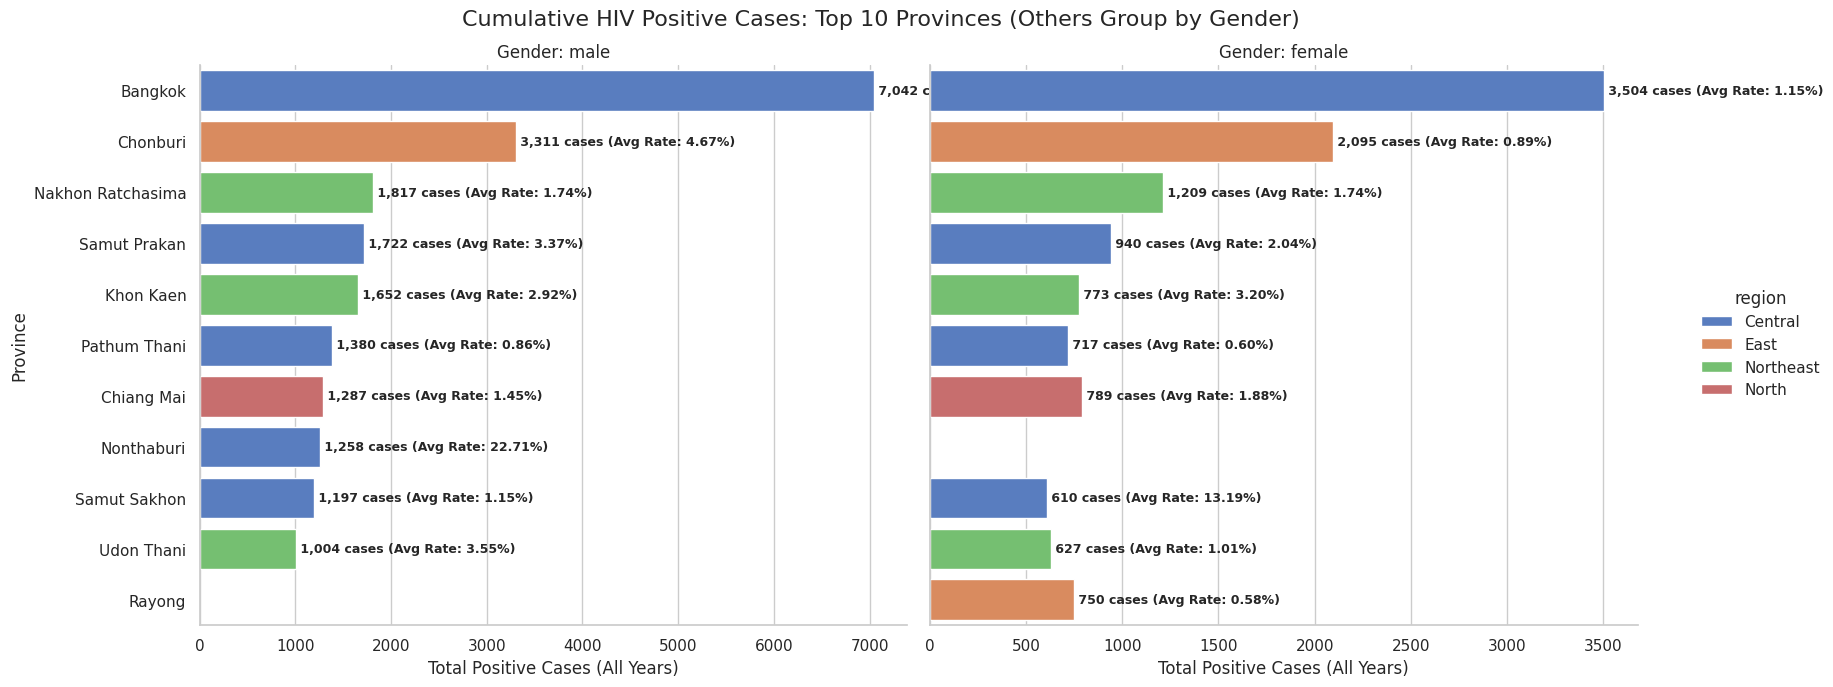

In [33]:
gender_prov_sum = df.groupby(['sex', 'region', 'province']).agg({
    'positive_others': 'sum',
    'test_others': 'sum'
}).reset_index()

# คำนวณอัตราการติดเชื้อเฉลี่ยสะสม (Overall Positivity Rate)
gender_prov_sum['positivity_rate'] = (gender_prov_sum['positive_others'] / gender_prov_sum['test_others'] * 100)

# 2. คัดเลือก Top 10 จังหวัดของแต่ละเพศ (จากยอดสะสมทุกปี)
male_top_sum = gender_prov_sum[gender_prov_sum['sex'] == 'male'].sort_values('positive_others', ascending=False).head(10)
female_top_sum = gender_prov_sum[gender_prov_sum['sex'] == 'female'].sort_values('positive_others', ascending=False).head(10)
plot_df_sum = pd.concat([male_top_sum, female_top_sum])

# 3. สร้างกราฟแยกชาย-หญิง (Cumulative Analysis)
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df_sum,
    kind="bar",
    x="positive_others",
    y="province",
    hue="region",
    col="sex",
    col_order=['male', 'female'],
    sharex=False, # แยกสเกลเพื่อให้เห็นรายละเอียดฝั่งผู้หญิง
    height=7,
    aspect=1.2,
    dodge=False,
    palette='muted'
)

# ปรับแต่ง Labels และ Titles
g.set_axis_labels("Total Positive Cases (All Years)", "Province")
g.set_titles("Gender: {col_name}")

for ax_idx, ax in enumerate(g.axes.flat):
    # เลือกข้อมูลให้ตรงกับฝั่งของกราฟ
    current_data = male_top_sum if ax_idx == 0 else female_top_sum

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        if width > 0:
            # ดึงค่า Rate เฉลี่ยสะสมมาแสดง
            rate = current_data.iloc[i]['positivity_rate']
            ax.text(width, p.get_y() + p.get_height()/2.,
                    f' {int(width):,} cases (Avg Rate: {rate:.2f}%)',
                    va='center', fontweight='bold', fontsize=9)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Cumulative HIV Positive Cases: Top 10 Provinces (Others Group by Gender)', fontsize=16)
plt.show()